#  Kolmogorov-Smirnov

## Định nghĩa
Kiểm định Kolmogorov-Smirnov là một phương pháp thống kê phi tham số dùng để so sánh hai phân phối xác suất. Khác với t-test yêu cầu dữ liệu phải tuân theo phân phối chuẩn, K-S Test có thể hoạt động trên bất kỳ hình dạng phân phối nào.

Trong quy trình tiền xử lý ảnh, Two-Sample K-S Test (K-S Test hai mẫu) được sử dụng để so sánh phân phối giá trị pixel của tập ảnh gốc ($X_{orig}$) và tập ảnh sau khi chuẩn hóa ($X_{norm}$).

**Giả thuyết thống kê:**
- **Giả thuyết ($H_0$):** Hai tập dữ liệu (Gốc và Đã chuẩn hóa) tuân theo cùng một phân phối xác suất.
- **Đối thuyết ($H_1$):** Hai tập dữ liệu tuân theo hai phân phối xác suất khác nhau.

## Công thức
Khi làm việc trên tập dữ liệu mẫu (các giá trị pixel rời rạc) thay vì một phương trình phân phối lý thuyết, K-S Test đo lường khoảng cách tuyệt đối lớn nhất giữa hai **Hàm phân phối tích lũy thực nghiệm (Empirical Cumulative Distribution Function - ECDF)**.

**Công thức ECDF của một mẫu dữ liệu:**

ECDF tính tỷ lệ phần trăm các điểm dữ liệu có giá trị nhỏ hơn hoặc bằng một mốc $x$ bất kỳ.

$$F_n(x) = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}_{ \{X_i \le x\} }$$

Trong đó:

- $n$: Tổng số lượng pixel.
- $x$: giá trị ngưỡng (threshold) bất kỳ trên trục hoành đang xét (một mức cường độ sáng cụ thể).
- $\mathbf{1}_{ \{X_i \le x\} }$: Hàm chỉ thị (trả về $1$ nếu giá trị pixel $X_i \le x$, ngược lại bằng $0$).

**Thống kê K-S ($D$) được tính bằng:**

$$D = \sup_{x} |F_{orig}(x) - F_{norm}(x)|$$

Trong đó:
- $F_{orig}(x)$: Đường ECDF của tập ảnh gốc.
- $F_{norm}(x)$: Đường ECDF của tập ảnh sau chuẩn hóa.
- $\sup_{x}$ (Supremum): Chênh lệch ECDF lớn nhất. Duyệt toàn bộ các mốc $x$ trên trục hoành để tìm ra vị trí mà chênh lệch giữa hai đường ECDF là lớn nhất.
- $D$: Nằm trong khoảng $[0, 1]$. Giá trị $D$ càng lớn, hai phân phối càng khác biệt về mặt hình dáng hoặc bị dịch chuyển càng xa nhau.

## Các bước kiểm định

1. **Làm phẳng dữ liệu (Flattening):** Chuyển ảnh nhiều chiều thành một vector 1D duy nhất chứa toàn bộ các giá trị pixel.
2. **Tính ECDF:** Sắp xếp các số trong chuỗi theo thứ tự tăng dần để vẽ thành đường cong phân phối cho từng tập dữ liệu.
3. **Đo khoảng cách $D$:** Tìm vị trí mà khoảng cách chênh lệch giữa hai đường cong vừa vẽ là lớn nhất.
4. **Tính p-value:** Dựa trên trị số $D$ và kích thước mẫu để tính ra giá trị $p-value$.
5. **Kết luận:** So sánh $p-value$ với mức ý nghĩa $\alpha$ (thông thường,$\alpha = 0.05$) để quyết định bác bỏ hay chấp nhận giả thuyết $H_0$.

## Ý nghĩa của p-value
**Trường hợp $p-value \le \alpha$ (Bác bỏ $H_0$):** phân phối khác biệt đáng kể. Chuẩn hóa tạo ra biến đổi trong miền giá trị.

**Trường hợp $p-value > \alpha$ (Chấp nhận $H_0$):** Ảnh gốc và ảnh sau chuẩn hóa đều chia sẻ chung một phân phối xác suất.

# Lý thuyết và Tiêu chí Đánh giá Chuẩn hóa Ảnh
**Mục đích:** Việc chuẩn hóa không chỉ đơn thuần là đưa giá trị về một khoảng nhất định mà còn nhằm:
- **Tăng tốc độ hội tụ:** Giúp hàm mất mát (Loss Function) có hình dạng tròn trịa hơn, tránh hiện tượng "zigzag" khi cập nhật trọng số bằng Gradient Descent. Zigzag là hiện tượng mà đường đi của Gradient Descent không hội tụ nhanh về cực tiểu mà di chuyển qua lại (zigzag) giữa các hướng dốc khác nhau, khiến việc hội tụ chậm hơn rất nhiều.
- **Đưa dữ liệu về vùng tuyến tính:** Giúp các hàm kích hoạt (như Sigmoid, Tanh) không bị rơi vào vùng bão hòa (Saturation) ngay từ đầu.

## Các phương pháp chuẩn hóa phổ biến
### MinMax scaling:
Phương pháp này chuyển đổi dữ liệu về một khoảng cố định (thường là $[0, 1]$, $[-1, 1]$).

- Công thức [0, 1]: $x' = \frac{x - \min(x)}{\max(x) - \min(x) + \epsilon}$
- Công thức [-1, 1]: $x' = 2 \cdot \frac{x - \min(x)}{\max(x) - \min(x) + \epsilon} - 1$
- Đặc điểm: Giữ nguyên mối quan hệ tuyến tính giữa các pixel nhưng cực kỳ nhạy cảm với nhiễu (Outliers). Một pixel nhiễu trắng có thể làm toàn bộ ảnh sau chuẩn hóa bị tối đi đáng kể.

### Z-Score Normalization
Đưa dữ liệu về phân phối có trung bình $\mu = 0$ và độ lệch chuẩn $\sigma = 1$.

Công thức: $x' = \frac{x - \mu}{\sigma + \epsilon}$

- **Z-Score Global:** Tính $\mu$ và $\sigma$ trên toàn bộ các pixel của tất cả các kênh màu (R, G, B) gộp lại. Giúp giữ nguyên tỷ lệ cường độ giữa các kênh màu. Nếu ảnh gốc bị ám vàng, ảnh sau chuẩn hóa vẫn giữ nguyên sắc thái đó.
- **Z-Score Channel-wise:** Tính $\mu_i$ và $\sigma_i$ riêng biệt cho từng kênh màu. Đây là kỹ thuật Cân bằng trắng (White Balance) mạnh mẽ. Nó ép mỗi kênh màu phải có cùng một phân phối, giúp loại bỏ sự sai lệch màu sắc do nguồn sáng gây ra.

## Các tiêu chí đánh giá chuẩn hóa
- **Tính dịch tâm về 0:** Đưa giá trị dữ liệu về mức $0$ làm trung tâm. Điều này giúp thuật toán tối ưu (như Gradient Descent) cập nhật trọng số linh hoạt theo mọi hướng, tránh hiện tượng "zigzag" làm chậm tốc độ huấn luyện.
- **Tính đồng nhất dải giá trị:** Các giá trị sau chuẩn hóa phải nằm trong dải cho phép (ví dụ: $[0, 1]$, $[-1, 1]$, ...). Nếu dải giá trị quá lớn hay quá nhỏ, nó sẽ gây ra hiện tượng Exploding/Vanishing Gradient.
- **Bảo toàn phân phối:** Hình dạng của Histogram (vị trí các đỉnh, thung lũng) phải tương đồng với ảnh gốc. Nếu Histogram bị biến dạng mạnh hoặc xuất hiện các khoảng trống, phép chuẩn hóa đó có thể gây mất mát thông tin.

In [1]:
import sys
import os
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('../src'))
from config.settings import PATH_FOLDER_IMAGE_RAW, PATH_FOLDER_IMAGE_TEST
from image.dataset import ImageDataset
from image.preprocessing_normalization import Normalization
from visualization.comparison import plot_normalization_comparison

dataset = ImageDataset(path=PATH_FOLDER_IMAGE_TEST)

# dùng batch đầu tiên để visualize
batch_generator = dataset.load()
first_batch, first_indices = next(batch_generator)
arr = first_batch[0].copy()

Method: minmax_01
  - min: 0.0000
  - max: 255.0000


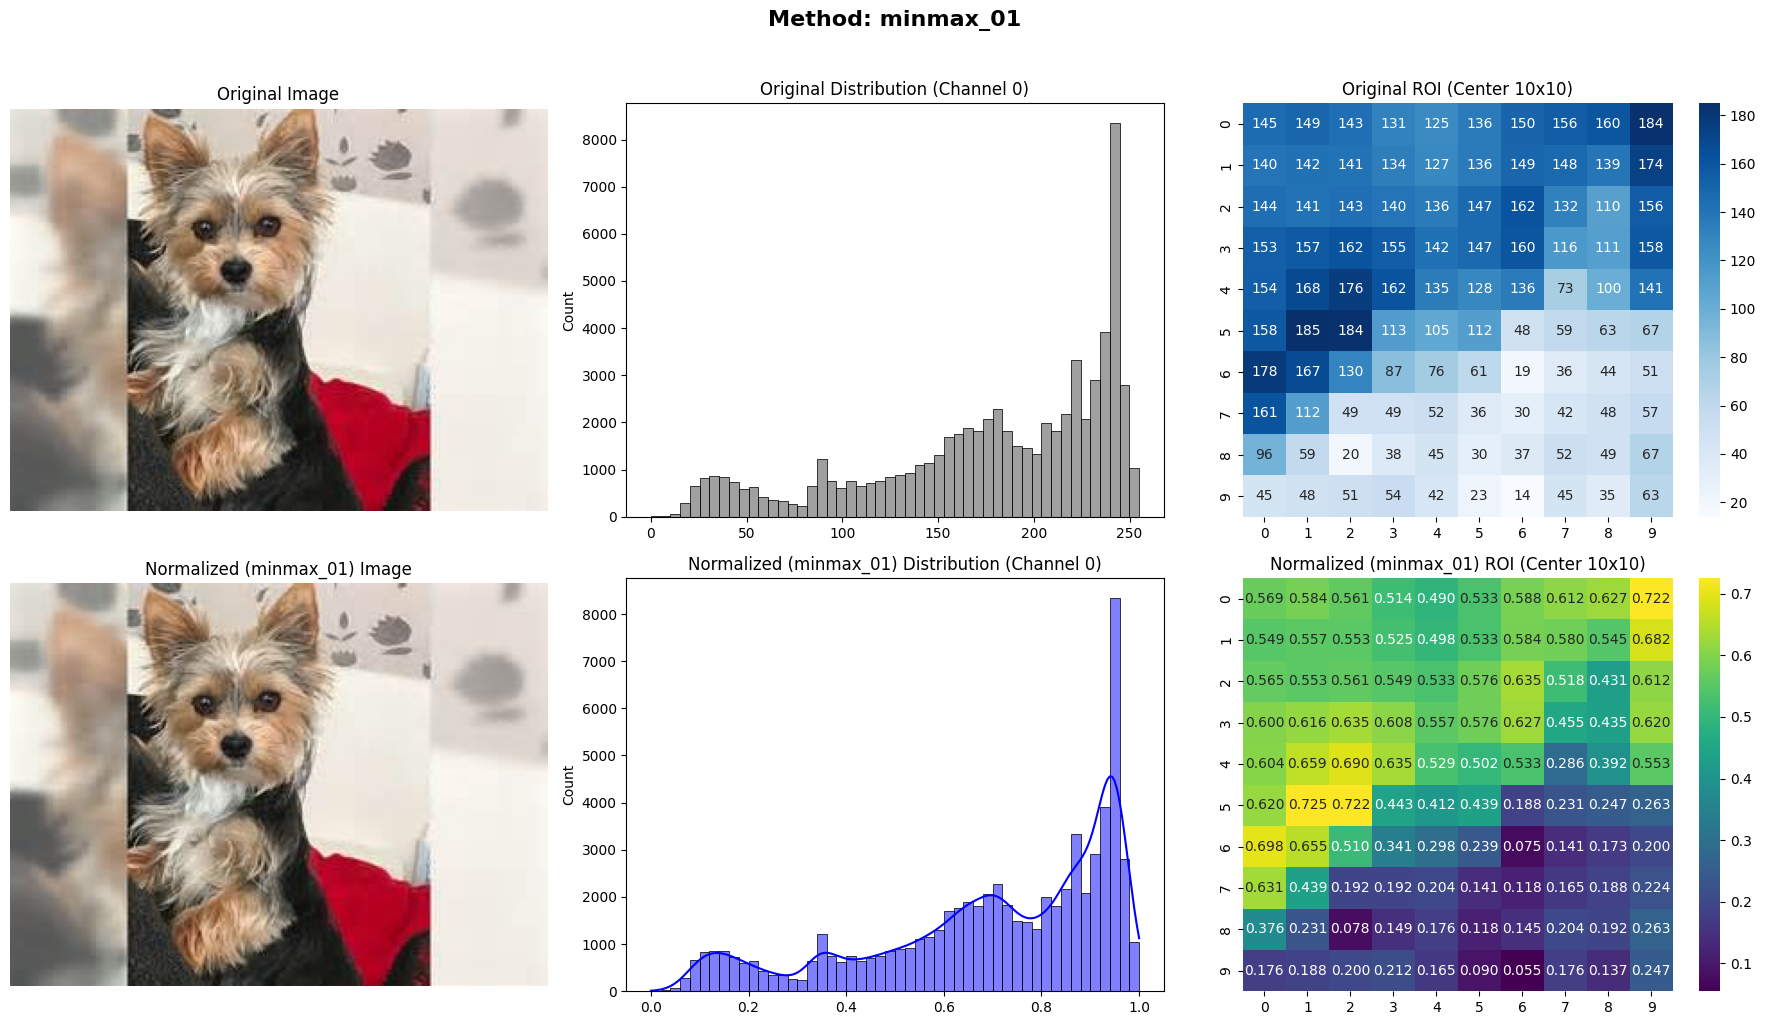

Method: minmax_m11
  - min: 0.0000
  - max: 255.0000


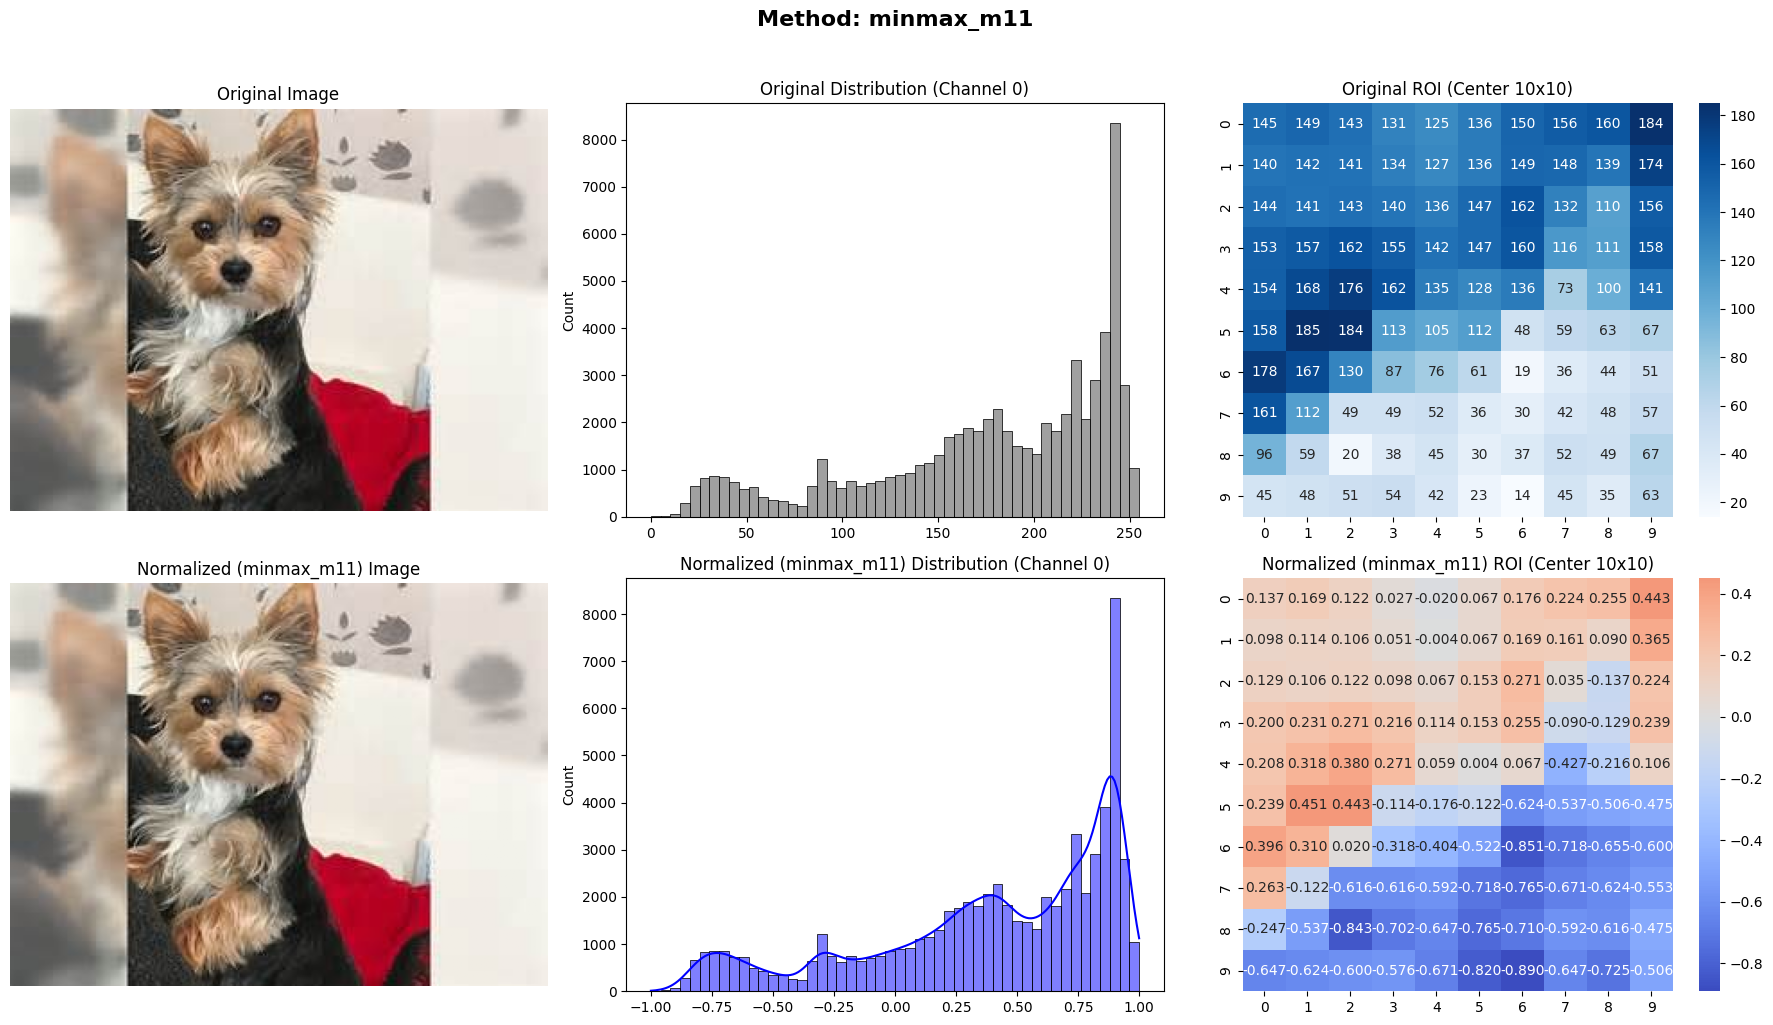

Method: zscore_global
  - mean: 162.6207
  - std: 69.3516


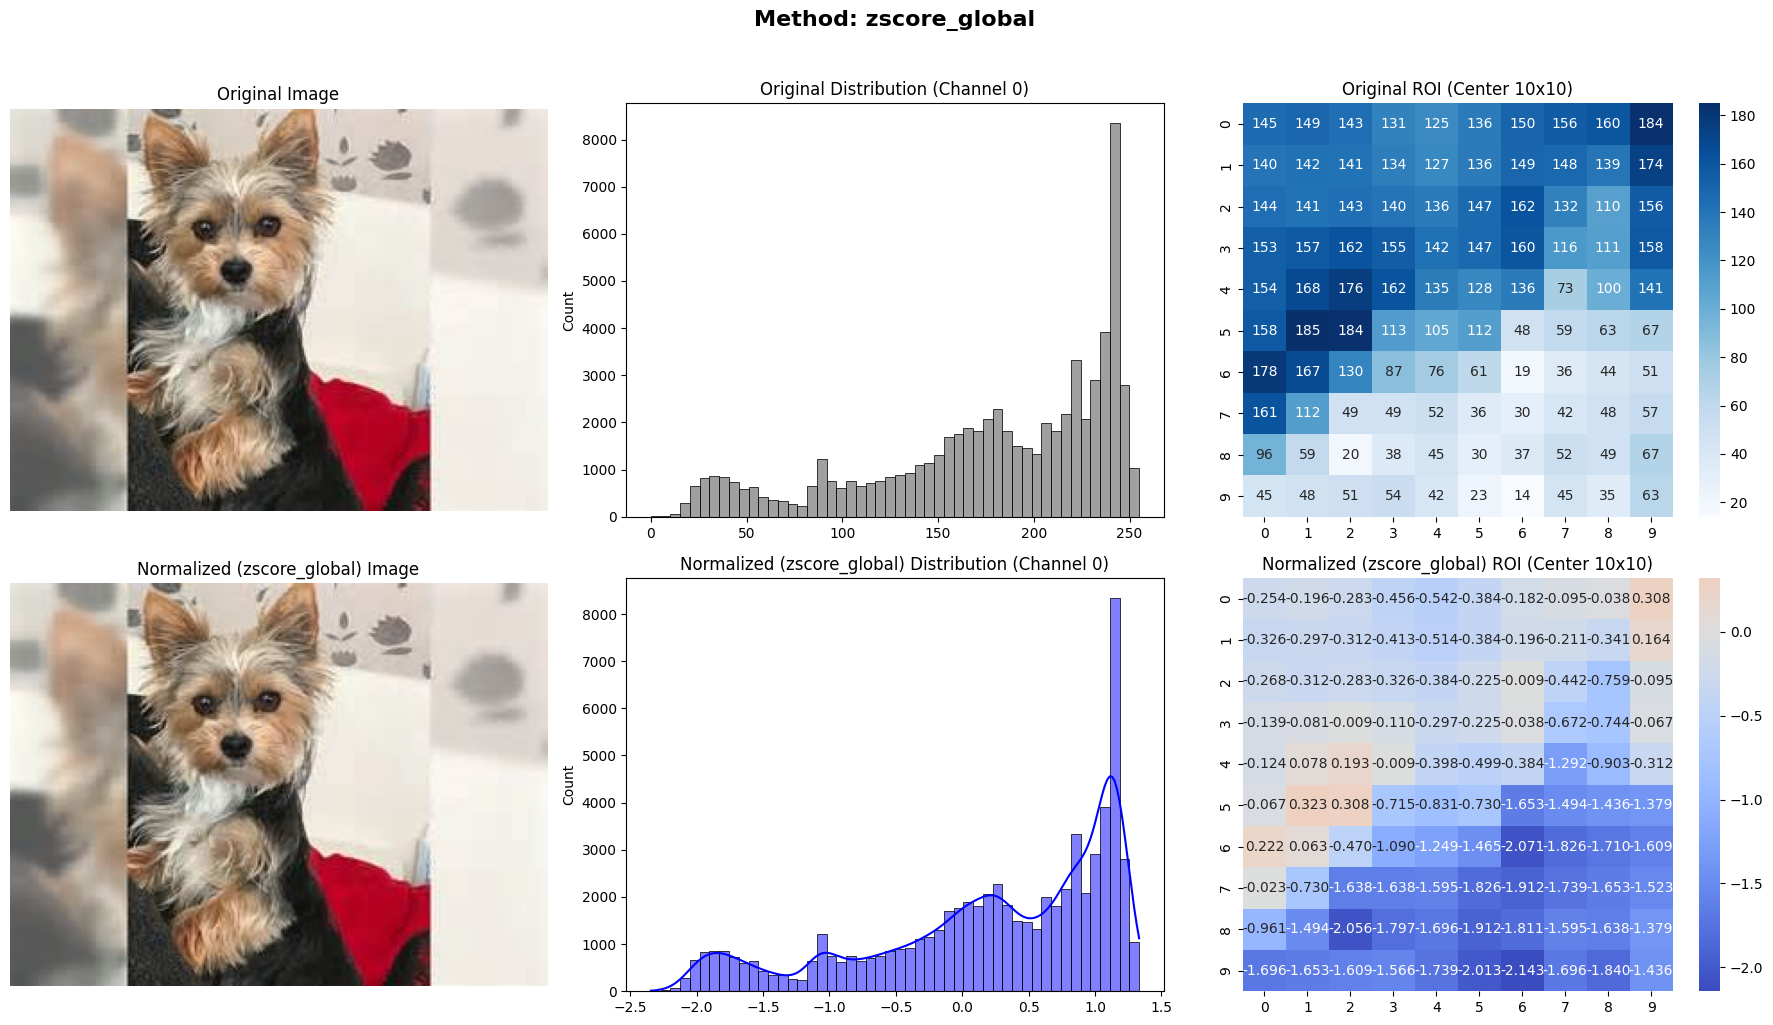

Method: zscore_channel
  - mean: [177.33030700683594, 160.193603515625, 150.33819580078125]
  - std: [63.93330001831055, 71.99720001220703, 69.1688003540039]


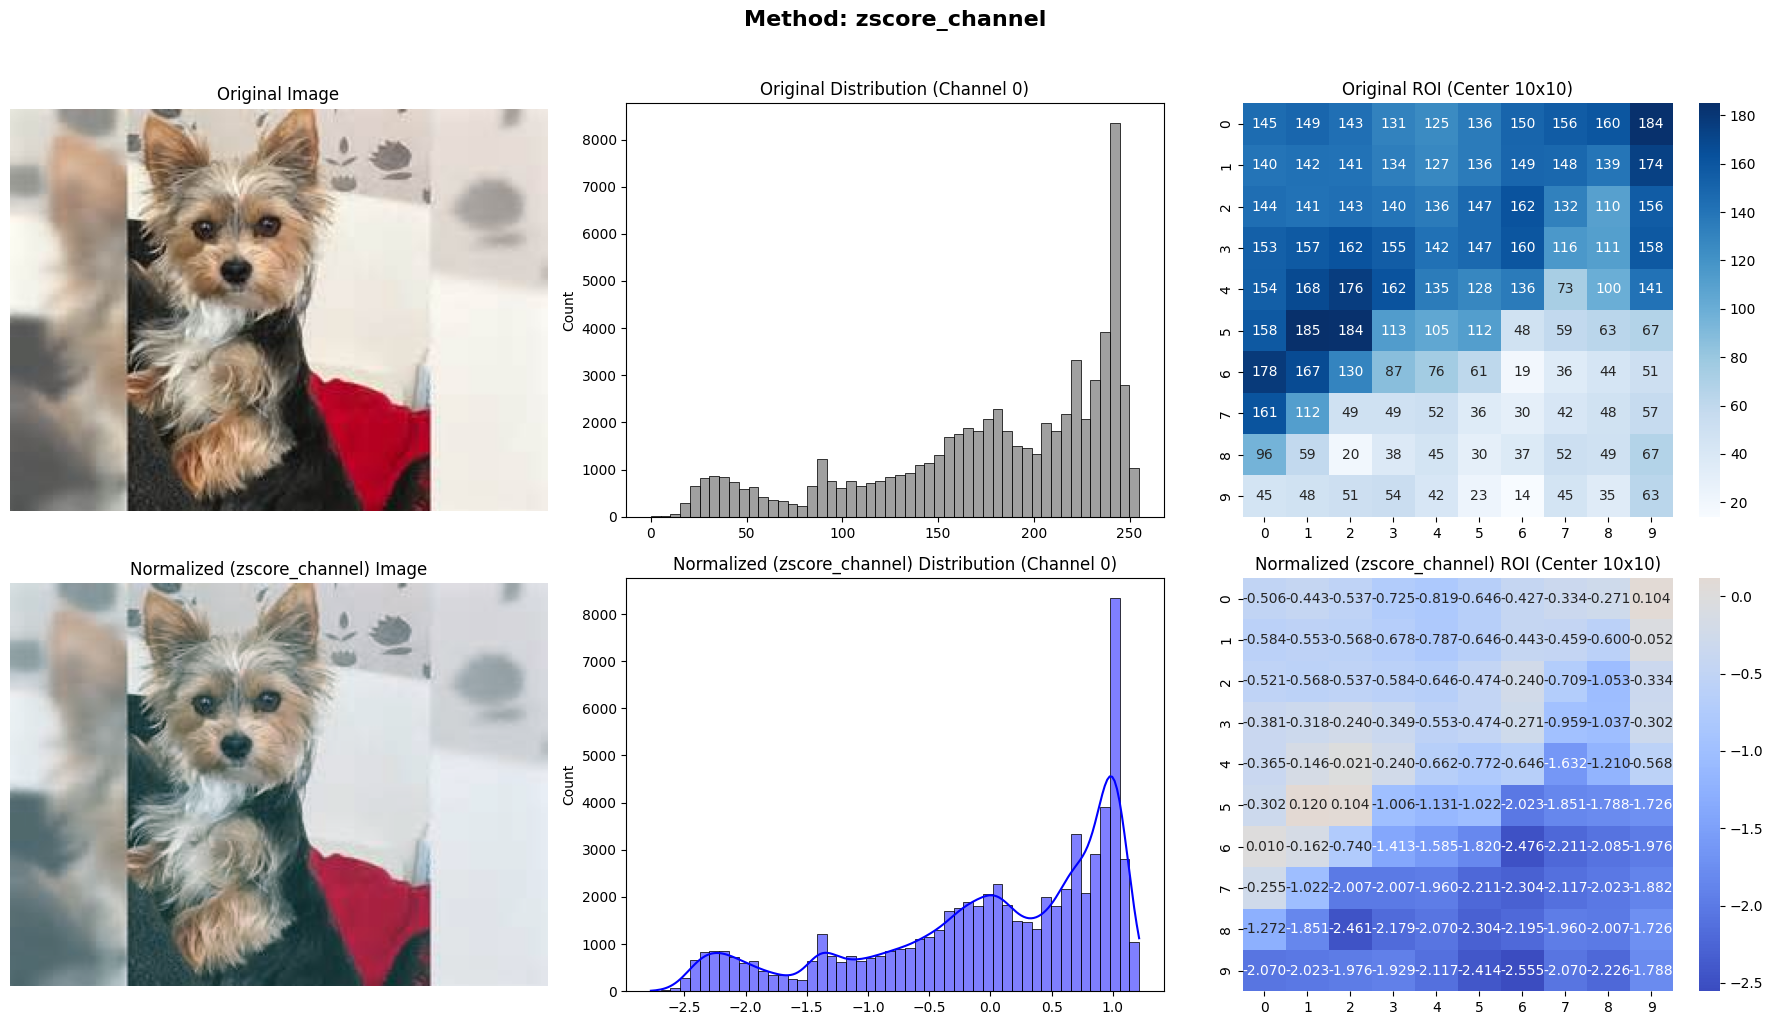

In [2]:
methods = ["minmax_01", "minmax_m11", "zscore_global", "zscore_channel"]

for method in methods:
    norm_tool = Normalization(method=method)
    img_normalized = norm_tool.fit_transform(arr=arr)
    norm_tool.log()
    plot_normalization_comparison(arr, img_normalized, method)

## Nhận xét các tiêu chí

**Tính dịch tâm về 0**

- **minmax_01:** Không có tính dịch tâm. Phân phối Histogram nằm ở phần dương của trục hoành (từ $0$ đến $1$), cho thấy không có mốc trung tâm $0$.
- **minmax_m11, zscore_global và zscore_channel:** Đều mang tính dịch tâm. Histogram có dữ liệu trải đều qua trục tung $0$. Trên biểu đồ Heatmap, giá trị $0$ được thể hiện bằng màu trắng, các pixel có giá trị âm (màu xanh) và giá trị dương (màu đỏ).

**Tính đồng nhất dải giá trị:** Nhìn chung các ảnh sau khi áp dụng các phương pháp chuẩn hóa đều cho kết quả nằm trong khoảng dự đoán.
- **minmax_01 và minmax_m11:** có các giá trị trong đoạn $[0, 1]$ và $[-1, 1]$.
- **zscore_global và zscore_channel:** Không có khoảng giá trị cố định $\min/\max$ mà tuân theo quy luật thống kê, dải giá trị phần lớn tập trung trong khoảng $[-2.5, 1.5]$.

**Bảo toàn phân phối:** Cả 4 phương pháp đều thỏa mãn tiêu chí này. Hình dáng phân phối các đỉnh và thung lũng đặc trưng của ảnh gốc được giữ nguyên trên Histogram của cả 4 kết quả. Không có hiện tượng biến dạng, gãy nứt hay xuất hiện các khoảng trống (gaps) bất thường. Điều này khẳng định các phép biến đổi là tuyến tính, không làm mất đi các đặc trưng cấu trúc ảnh.